In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

air = pd.read_csv("../data/air_quality.csv")
weather = pd.read_csv("../data/weather_hourly.csv")

air["time"] = pd.to_datetime(air["time"])
weather["time"] = pd.to_datetime(weather["time"])

df = pd.merge(air, weather, on="time")

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1806528 entries, 0 to 1806527
Data columns (total 29 columns):
 #   Column                 Dtype                    
---  ------                 -----                    
 0   city_x                 object                   
 1   state_x                object                   
 2   zip_x                  int64                    
 3   time                   datetime64[ns, UTC-06:00]
 4   us_aqi                 float64                  
 5   pm10                   float64                  
 6   pm2_5                  float64                  
 7   carbon_monoxide        float64                  
 8   nitrogen_dioxide       float64                  
 9   sulphur_dioxide        float64                  
 10  ozone                  float64                  
 11  uv_index_clear_sky     float64                  
 12  uv_index               float64                  
 13  dust                   float64                  
 14  aerosol_optical_de

In [20]:
df.describe()

,zip_x,us_aqi,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,uv_index_clear_sky,uv_index,...,relative_humidity_2m,precipitation,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m,shortwave_radiation,diffuse_radiation,cloud_cover
count,1.806528e+06,1.806528e+06,1.806528e+06,1.806528e+06,1.806528e+06,1.806528e+06,1.806528e+06,1.806528e+06,1.806528e+06,1.806528e+06,...,1.806528e+06,1.806528e+06,1.806528e+06,1.806528e+06,1.806528e+06,1.806528e+06,1.806528e+06,1.806528e+06,1.806528e+06,1.806528e+06
mean,7.705159e+04,5.195259e+01,1.546376e+01,1.365034e+01,2.073210e+02,1.535049e+01,2.997444e+00,6.263654e+01,1.307050e+00,1.075440e+00,...,7.634461e+01,1.295640e-02,1.134955e+01,2.036143e+01,2.011830e+02,1.971464e+02,2.582604e+01,1.867332e+02,5.771338e+01,4.849168e+01
std,3.206108e+01,1.370624e+01,8.208826e+00,7.545171e+00,5.006334e+01,1.072282e+01,1.441089e+00,2.508562e+01,2.036488e+00,1.724691e+00,...,2.123654e+01,5.933284e-02,5.179678e+00,7.856702e+00,9.998425e+01,9.864683e+01,1.148112e+01,2.585705e+02,8.028920e+01,4.283543e+01
min,7.700200e+04,2.472223e+01,1.300000e+00,1.300000e+00,1.260000e+02,1.200000e+00,7.000000e-01,1.000000e+01,0.000000e+00,0.000000e+00,...,1.925934e+01,0.000000e+00,0.000000e+00,2.545584e-01,4.981988e-01,2.652484e-01,1.440000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,7.702600e+04,3.939236e+01,8.900000e+00,7.200000e+00,1.680000e+02,6.600000e+00,2.000000e+00,4.400000e+01,0.000000e+00,0.000000e+00,...,6.072482e+01,0.000000e+00,7.001514e+00,1.530741e+01,1.472648e+02,1.523006e+02,1.620000e+01,0.000000e+00,0.000000e+00,2.000000e+00
50%,7.705000e+04,5.435283e+01,1.490000e+01,1.280000e+01,1.960000e+02,1.270000e+01,2.700000e+00,6.500000e+01,0.000000e+00,0.000000e+00,...,8.329803e+01,0.000000e+00,1.145088e+01,2.074573e+01,1.819749e+02,1.836522e+02,2.592000e+01,0.000000e+00,0.000000e+00,4.300000e+01
75%,7.707500e+04,6.121453e+01,2.000000e+01,1.830000e+01,2.350000e+02,2.130000e+01,3.700000e+00,8.100000e+01,1.912500e+00,1.550000e+00,...,9.493057e+01,0.000000e+00,1.531931e+01,2.548192e+01,3.018093e+02,2.636057e+02,3.528000e+01,4.020000e+02,1.010000e+02,1.000000e+02
max,7.720400e+04,8.513298e+01,4.230000e+01,3.890000e+01,4.640000e+02,5.460000e+01,9.500000e+00,1.180000e+02,6.500000e+00,6.000000e+00,...,1.000000e+02,2.200000e+00,2.800606e+01,4.181621e+01,3.600000e+02,3.600000e+02,6.084000e+01,8.380000e+02,3.530000e+02,1.000000e+02


In [21]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)

city_x                   0
city_y                   0
diffuse_radiation        0
shortwave_radiation      0
wind_gusts_10m           0
wind_direction_100m      0
wind_direction_10m       0
wind_speed_100m          0
wind_speed_10m           0
precipitation            0
relative_humidity_2m     0
temperature_2m           0
zip_y                    0
state_y                  0
aerosol_optical_depth    0
state_x                  0
dust                     0
uv_index                 0
uv_index_clear_sky       0
ozone                    0
sulphur_dioxide          0
nitrogen_dioxide         0
carbon_monoxide          0
pm2_5                    0
pm10                     0
us_aqi                   0
time                     0
zip_x                    0
cloud_cover              0
dtype: int64


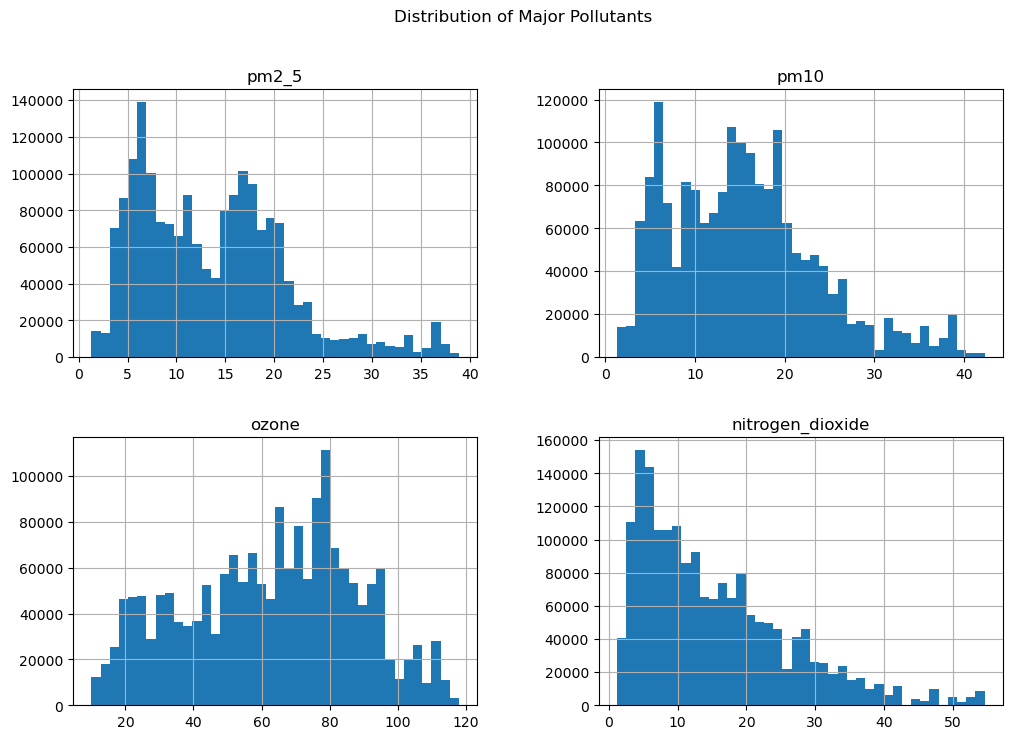

In [22]:
pollutants = ["pm2_5","pm10","ozone","nitrogen_dioxide"]

df[pollutants].hist(figsize=(12,8), bins=40)
plt.suptitle("Distribution of Major Pollutants")
plt.show()

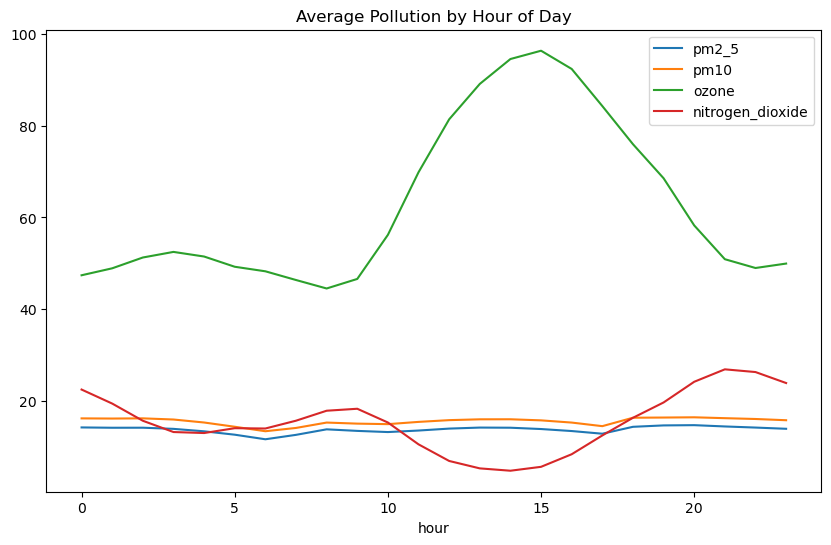

In [23]:
df["hour"] = df["time"].dt.hour

hourly = df.groupby("hour")[pollutants].mean()

hourly.plot(figsize=(10,6))
plt.title("Average Pollution by Hour of Day")
plt.show()

PM2.5 levels increase during early morning and evening hours, likely associated with traffic emissions.

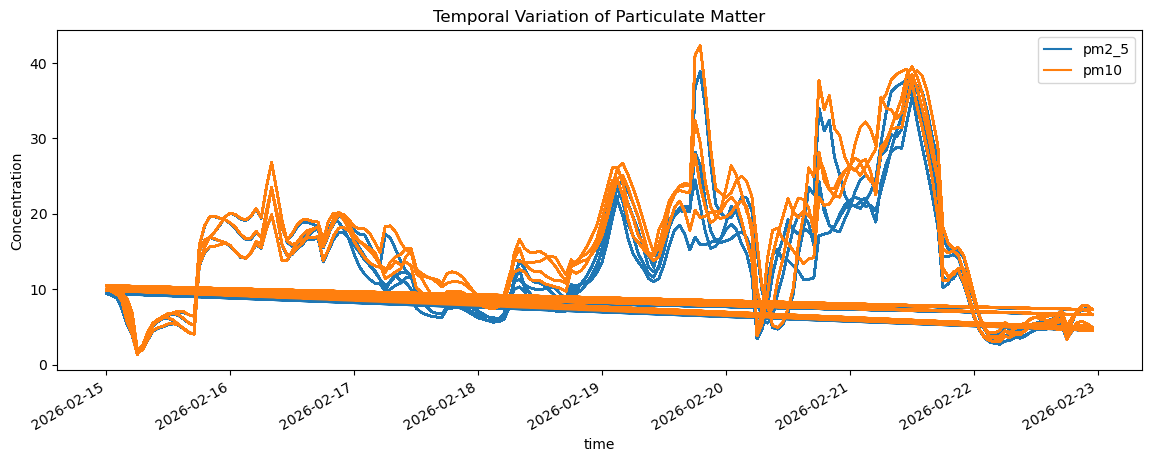

In [24]:
df.set_index("time")[["pm2_5","pm10"]].plot(figsize=(14,5))
plt.title("Temporal Variation of Particulate Matter")
plt.ylabel("Concentration")
plt.show()

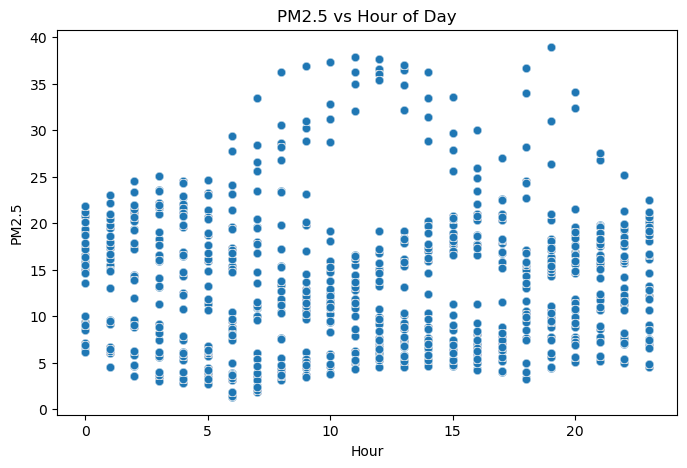

In [38]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="hour", y="pm2_5", data=df, alpha=0.3)
plt.title("PM2.5 vs Hour of Day")
plt.xlabel("Hour")
plt.ylabel("PM2.5")
plt.show()

Weekday pollution levels exceed weekend values, suggesting human activity patterns.

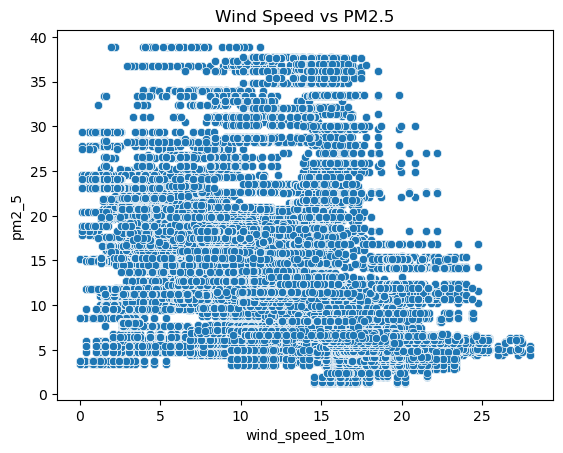

In [26]:
sns.scatterplot(x=df["wind_speed_10m"], y=df["pm2_5"])
plt.title("Wind Speed vs PM2.5")
plt.show()

In [27]:
zip_summary1 = df.groupby("zip_x").agg({
    "pm2_5": "mean",
    "pm10": "mean",
    "ozone": "mean",
    "dust": "mean",
    "carbon_monoxide": "mean",
    "nitrogen_dioxide": "mean",
    "sulphur_dioxide": "mean"
})

zip_summary1

,pm2_5,pm10,ozone,dust,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide
zip_x,,,,,,,
77002,13.497396,15.441146,60.588542,0.348958,217.776042,16.621354,2.923958
77003,13.497396,15.441146,60.588542,0.348958,209.255208,16.621354,2.923958
77004,13.497396,15.441146,60.588542,0.348958,211.088542,16.621354,2.923958
77005,13.613021,15.470312,63.604167,0.484375,211.088542,15.006250,3.158854
77006,13.497396,15.441146,60.588542,0.348958,211.088542,16.621354,2.923958
...,...,...,...,...,...,...,...
77095,14.082812,15.609896,61.890625,0.510417,202.614583,16.076042,3.154688
77096,13.613021,15.470312,63.604167,0.484375,209.968750,15.006250,3.158854
77098,13.613021,15.470312,63.604167,0.484375,211.088542,15.006250,3.158854


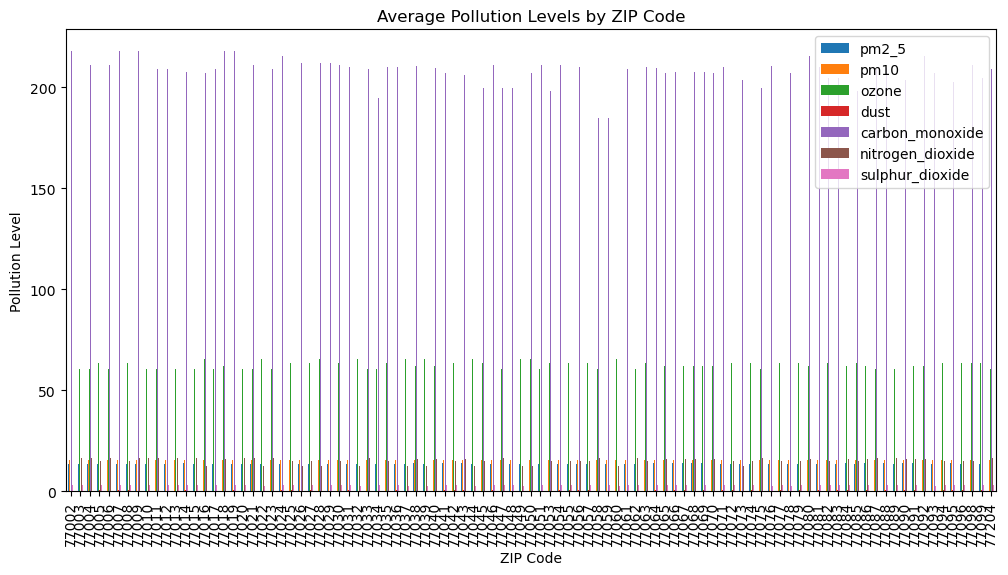

In [28]:
zip_summary1.plot(kind="bar", figsize=(12,6))

plt.title("Average Pollution Levels by ZIP Code")
plt.xlabel("ZIP Code")
plt.ylabel("Pollution Level")

plt.show()

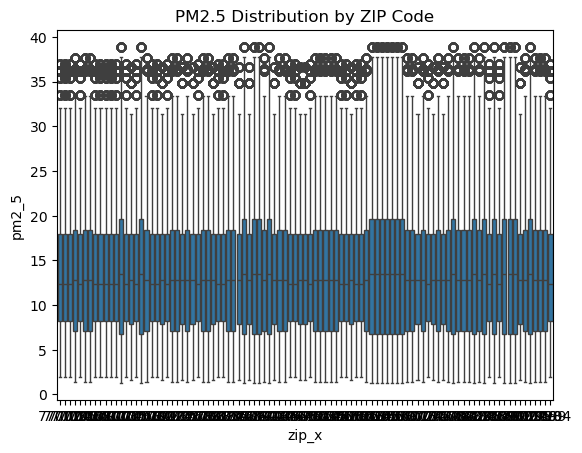

In [29]:
import seaborn as sns

sns.boxplot(x="zip_x", y="pm2_5", data=df)

plt.title("PM2.5 Distribution by ZIP Code")
plt.show()

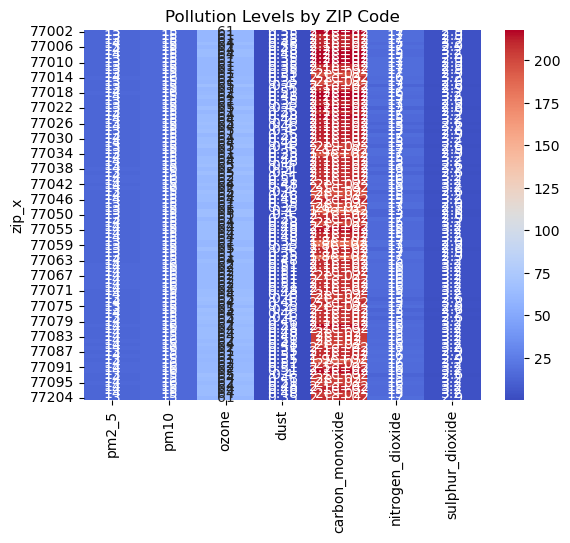

In [30]:
import seaborn as sns

sns.heatmap(zip_summary1, cmap="coolwarm", annot=True)

plt.title("Pollution Levels by ZIP Code")
plt.show()

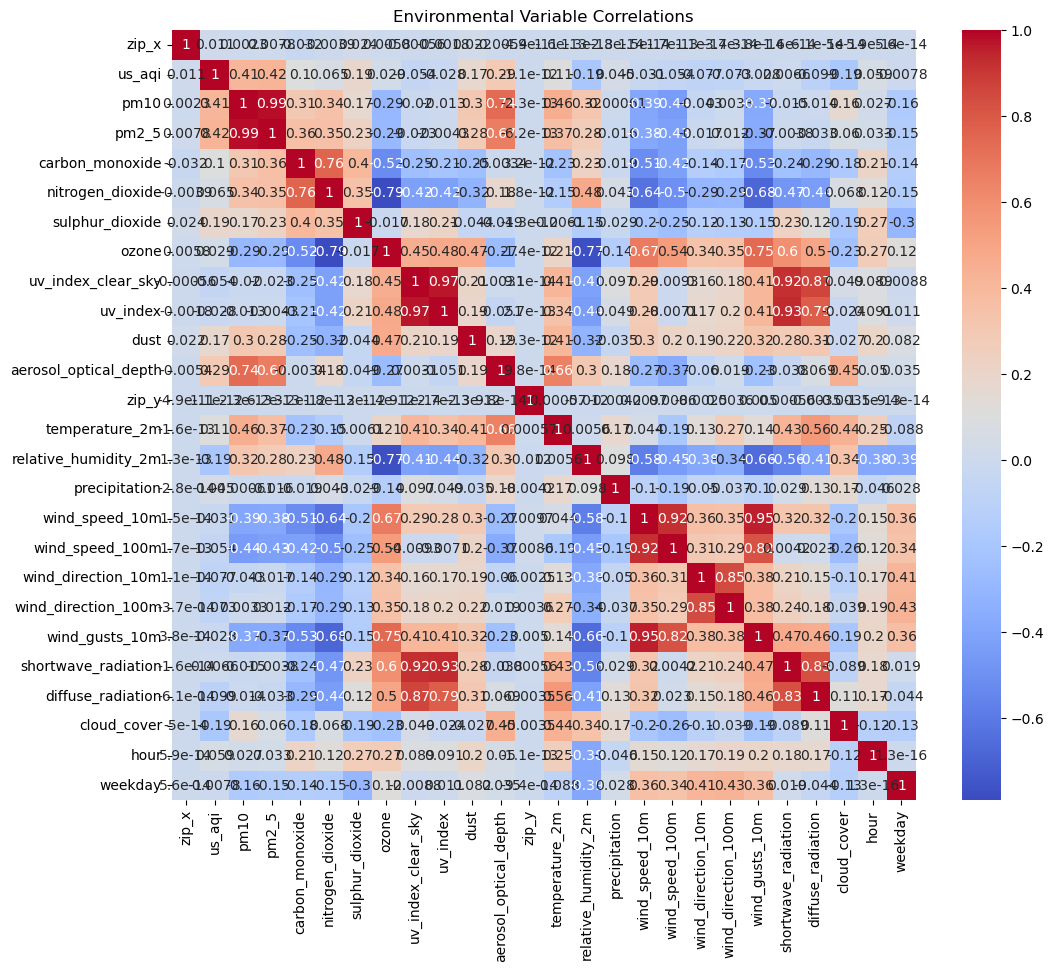

In [31]:

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Environmental Variable Correlations")
plt.show()

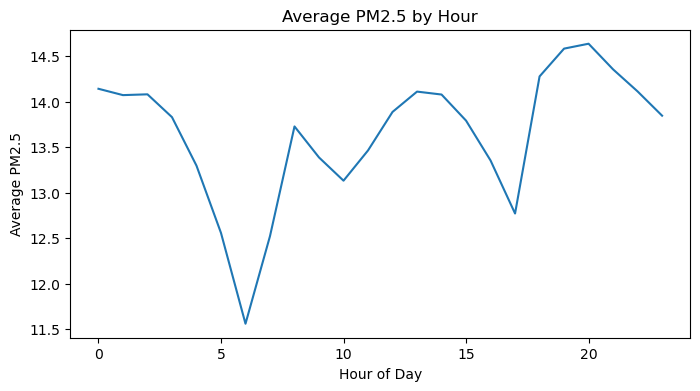

In [32]:
hourly_pm25 = df.groupby("hour")["pm2_5"].mean()

plt.figure(figsize=(8,4))
plt.plot(hourly_pm25.index, hourly_pm25.values)
plt.xlabel("Hour of Day")
plt.ylabel("Average PM2.5")
plt.title("Average PM2.5 by Hour")
plt.show()


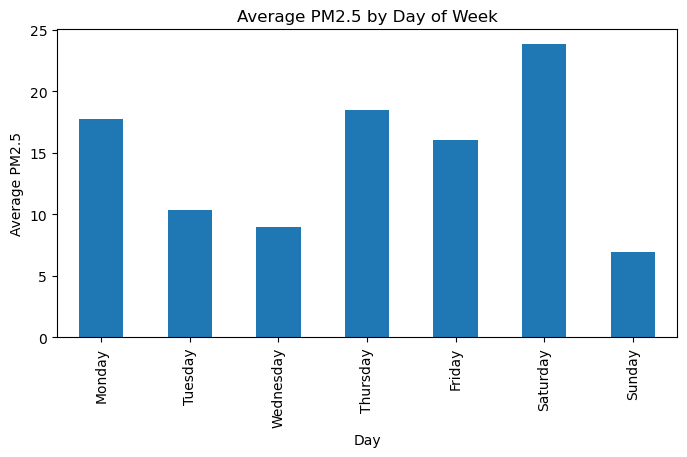

In [37]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
df["day_name"] = df["time"].dt.day_name()

weekday_pm25 = df.groupby("day_name")["pm2_5"].mean().reindex(day_order)

plt.figure(figsize=(8,4))
weekday_pm25.plot(kind="bar")
plt.title("Average PM2.5 by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average PM2.5")
plt.show()


## Dimensionality Reduction

High-dimensional environmental datasets may contain redundant information. Principal Component Analysis (PCA) is used to identify dominant pollution patterns and reduce dimensionality.

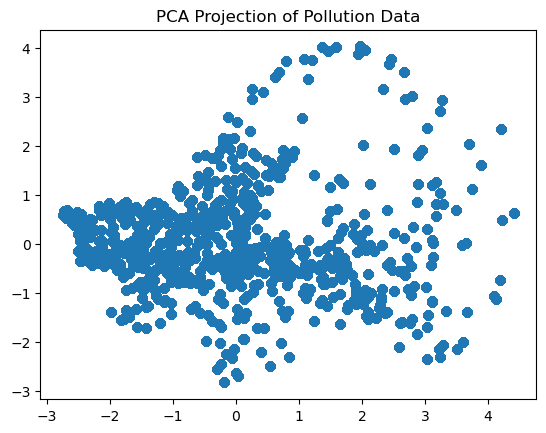

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = df[pollutants].dropna()

scaled = StandardScaler().fit_transform(features)

pca = PCA(n_components=2)
components = pca.fit_transform(scaled)

plt.scatter(components[:,0], components[:,1])
plt.title("PCA Projection of Pollution Data")
plt.show()

c:\Users\49\anaconda3\ICG\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


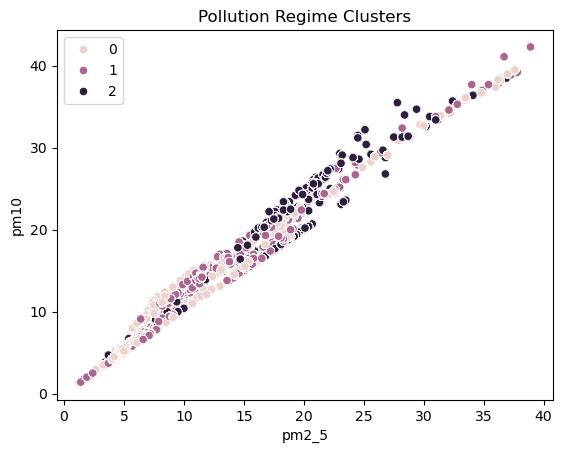

In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)

labels = kmeans.fit_predict(features)

sns.scatterplot(x=features["pm2_5"], y=features["pm10"], hue=labels)
plt.title("Pollution Regime Clusters")
plt.show()

Three pollution regimes emerge, potentially representing low, moderate, and high pollution conditions. The clustering analysis reveals distinct pollution regimes that may correspond to different environmental conditions such as clean air periods, moderate pollution, and high pollution episodes.

In [45]:
df["month"] = df["time"].dt.month
df["hour"] = df["time"].dt.hour
df["weekday"] = df["time"].dt.dayofweek

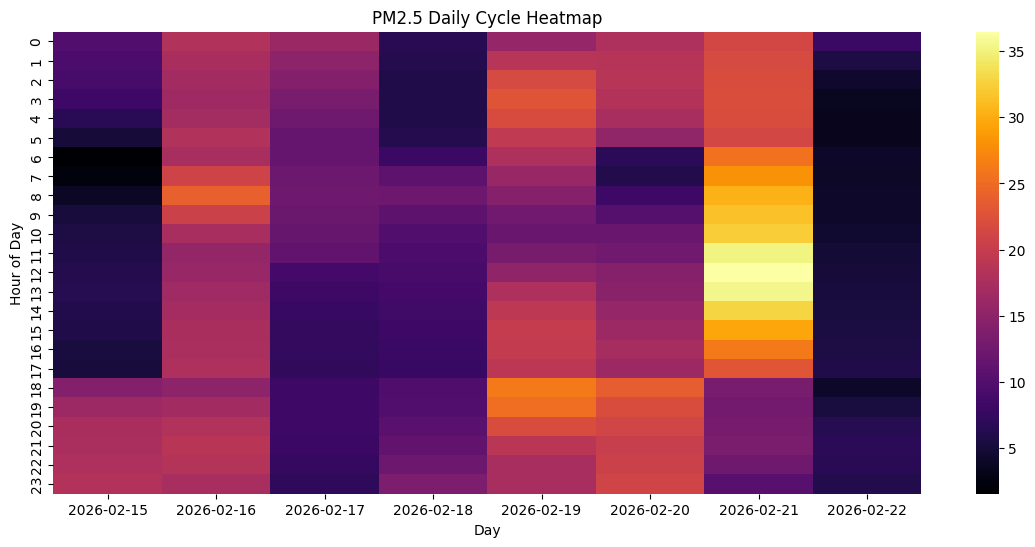

In [46]:
df["hour"] = df["time"].dt.hour
df["day"] = df["time"].dt.date

heatmap_data = df.pivot_table(
    values="pm2_5",
    index="hour",
    columns="day",
    aggfunc="mean"
)

plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data, cmap="inferno")
plt.title("PM2.5 Daily Cycle Heatmap")
plt.xlabel("Day")
plt.ylabel("Hour of Day")
plt.show()

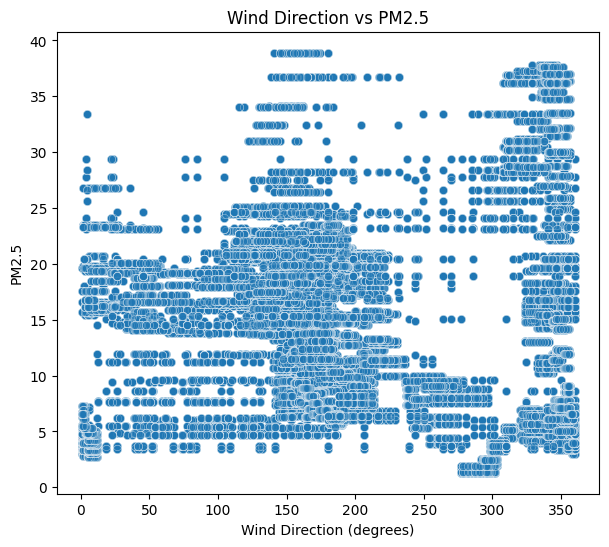

In [47]:
plt.figure(figsize=(7,6))

sns.scatterplot(
    x=df["wind_direction_10m"],
    y=df["pm2_5"],
    alpha=0.4
)

plt.title("Wind Direction vs PM2.5")
plt.xlabel("Wind Direction (degrees)")
plt.ylabel("PM2.5")
plt.show()

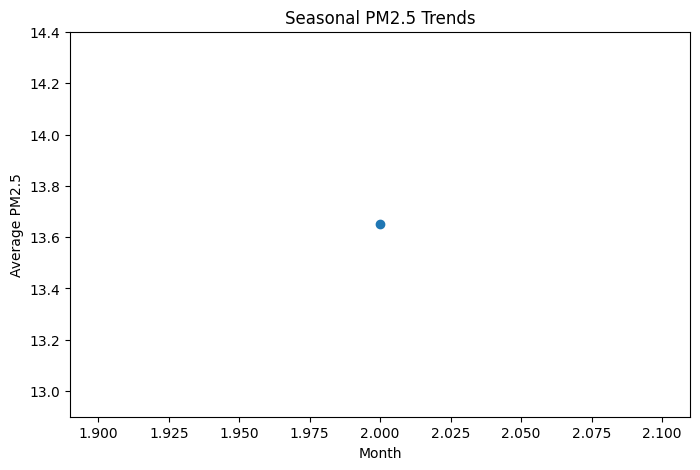

In [48]:
df["month"] = df["time"].dt.month

monthly = df.groupby("month")["pm2_5"].mean()

monthly.plot(marker="o", figsize=(8,5))
plt.title("Seasonal PM2.5 Trends")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.show()

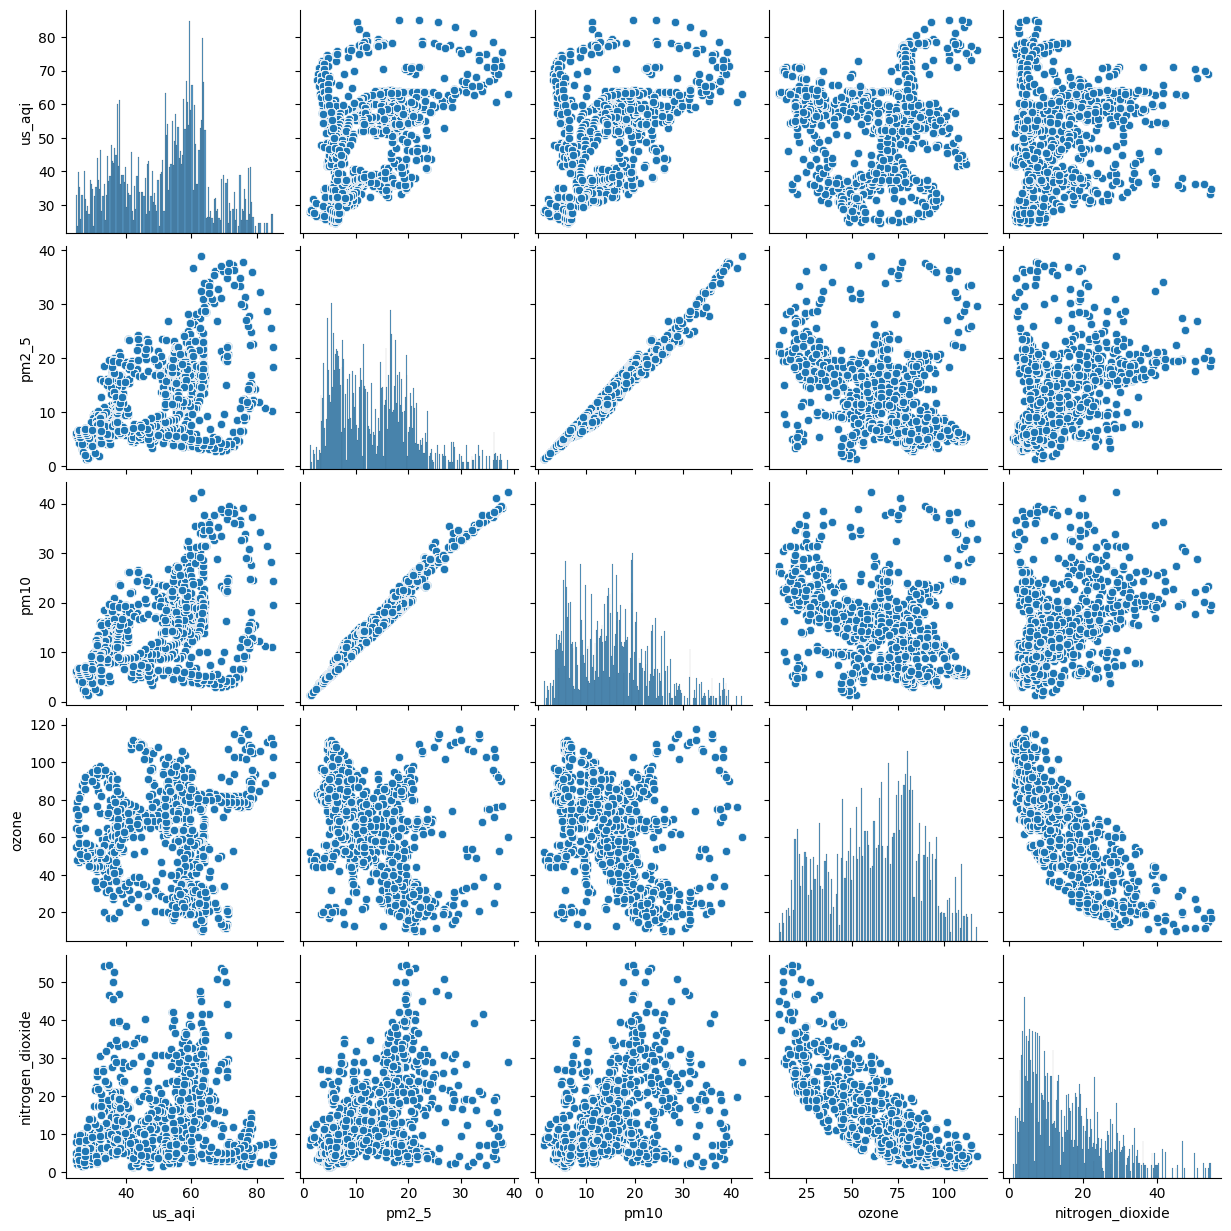

In [49]:






sns.pairplot(df[["us_aqi","pm2_5","pm10","ozone","nitrogen_dioxide"]])
plt.show()

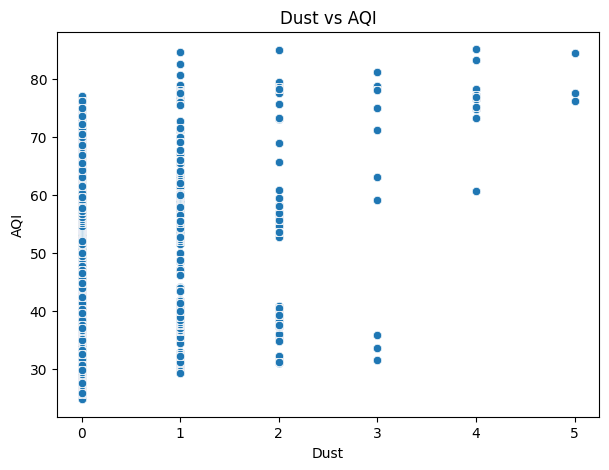

In [50]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df["dust"], y=df["us_aqi"])
plt.title("Dust vs AQI")
plt.xlabel("Dust")
plt.ylabel("AQI")
plt.show()

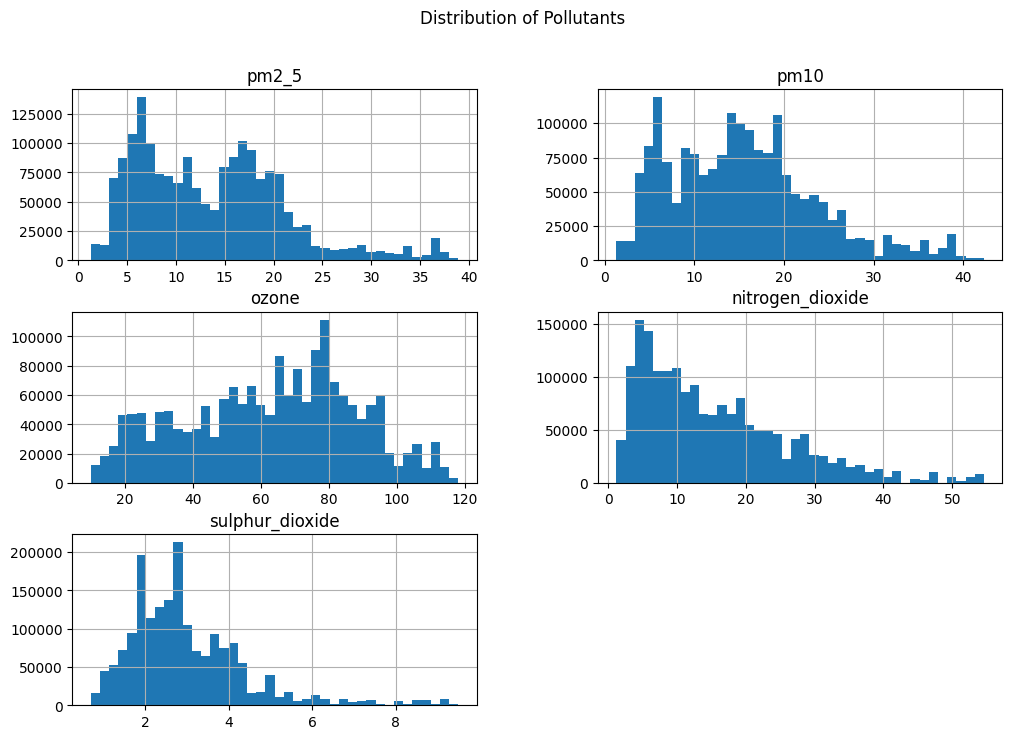

In [51]:
pollutants = ["pm2_5","pm10","ozone","nitrogen_dioxide","sulphur_dioxide"]

df[pollutants].hist(figsize=(12,8), bins=40)
plt.suptitle("Distribution of Pollutants")
plt.show()

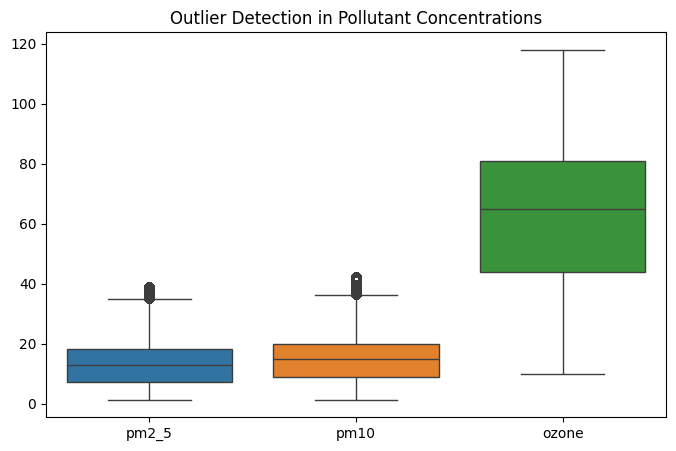

In [52]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[["pm2_5","pm10","ozone"]])
plt.title("Outlier Detection in Pollutant Concentrations")
plt.show()

Several extreme values appear in particulate matter concentrations, representing potential pollution episodes.

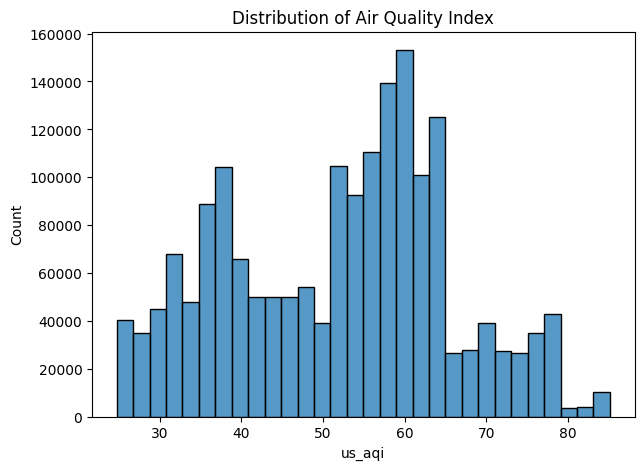

In [53]:
plt.figure(figsize=(7,5))
sns.histplot(df["us_aqi"], bins=30)
plt.title("Distribution of Air Quality Index")
plt.show()

The AQI distribution indicates that most observations fall within moderate pollution levels, with occasional spikes representing poor air quality events.

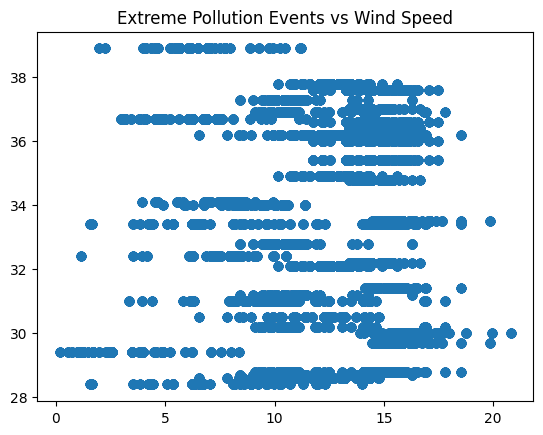

In [54]:

extreme = df[df["pm2_5"] > df["pm2_5"].quantile(0.95)]

plt.scatter(extreme["wind_speed_10m"], extreme["pm2_5"])
plt.title("Extreme Pollution Events vs Wind Speed")
plt.show()

Extreme pollution events tend to occur during periods of low wind speed, suggesting limited atmospheric dispersion.

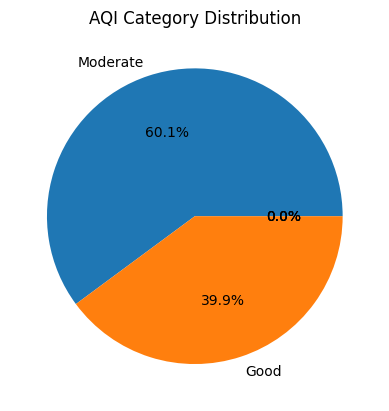

In [55]:
aqi_bins = pd.cut(df["us_aqi"],
                  bins=[0,50,100,150,200,300],
                  labels=["Good","Moderate","Unhealthy","Very Unhealthy","Hazardous"])

aqi_bins.value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("AQI Category Distribution")
plt.ylabel("")
plt.show()

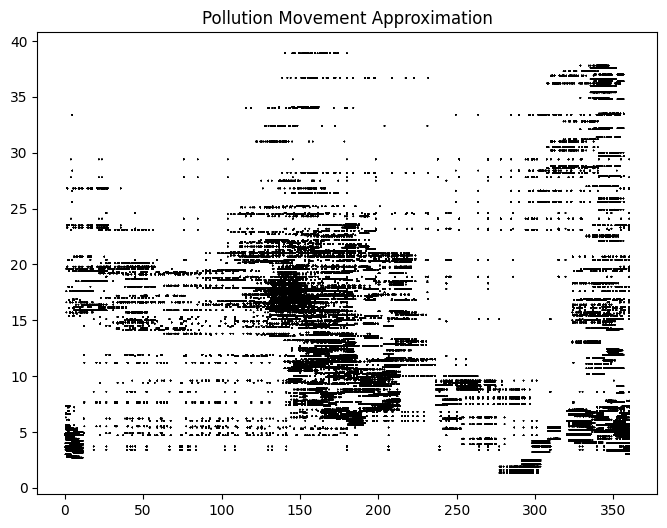

In [56]:
plt.figure(figsize=(8,6))

plt.quiver(
    df["wind_direction_10m"],
    df["pm2_5"],
    df["wind_speed_10m"],
    df["pm2_5"],
    alpha=0.5
)

plt.title("Pollution Movement Approximation")
plt.show()

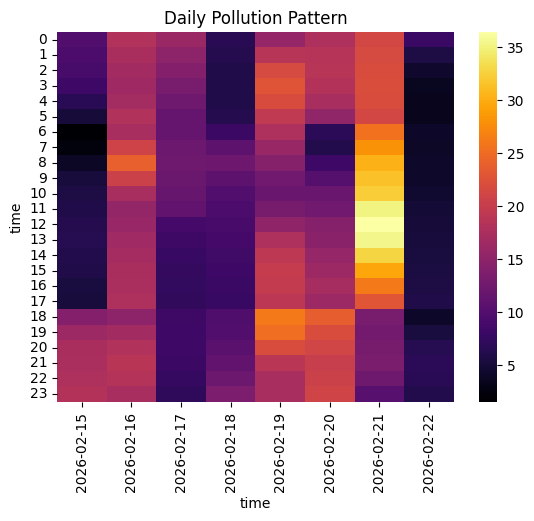

In [57]:
heatmap = df.pivot_table(
    values="pm2_5",
    index=df["time"].dt.hour,
    columns=df["time"].dt.date,
    aggfunc="mean"
)

sns.heatmap(heatmap, cmap="inferno")
plt.title("Daily Pollution Pattern")
plt.show()

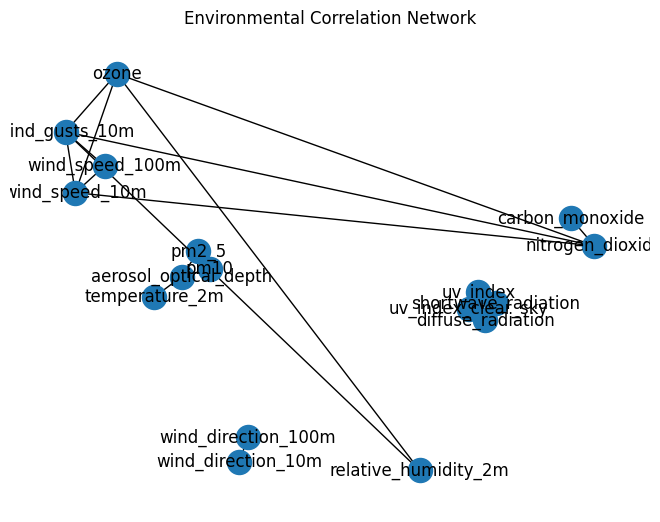

In [58]:
import networkx as nx

corr = df.corr(numeric_only=True)

G = nx.Graph()

for i in corr.columns:
    for j in corr.columns:
        if abs(corr.loc[i,j]) > 0.6 and i != j:
            G.add_edge(i,j,weight=corr.loc[i,j])

nx.draw(G, with_labels=True)
plt.title("Environmental Correlation Network")
plt.show()

In [59]:
df["air_binary"] = (df["pm2_5"] >= 35).astype(int)
df["air_binary"].value_counts()

,count
air_binary,
0,1773063
1,33465


0 = good air

1 = bad air

good air: PM2.5 < 35

bad air: PM2.5 ≥ 35

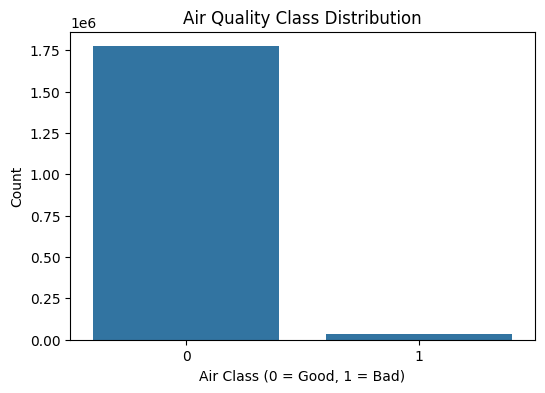

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="air_binary", data=df)
plt.title("Air Quality Class Distribution")
plt.xlabel("Air Class (0 = Good, 1 = Bad)")
plt.ylabel("Count")
plt.show()

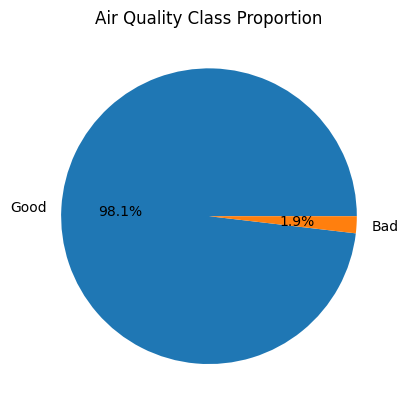

In [61]:
df["air_binary"].value_counts().plot(kind="pie", autopct="%1.1f%%", labels=["Good", "Bad"])
plt.title("Air Quality Class Proportion")
plt.ylabel("")
plt.show()

The binary target variable shows the proportion of good versus bad air observations. This can important because strong class imbalance may affect neural network training and evaluation.

In [62]:
df["hour"] = df["time"].dt.hour
df["weekday"] = df["time"].dt.dayofweek
df["month"] = df["time"].dt.month

In [63]:
features = [
    "pm10",
    "ozone",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "dust",
    "aerosol_optical_depth",
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "wind_direction_10m",
    "hour",
    "weekday",
    "month"
]

X = df[features]
y = df["air_binary"]

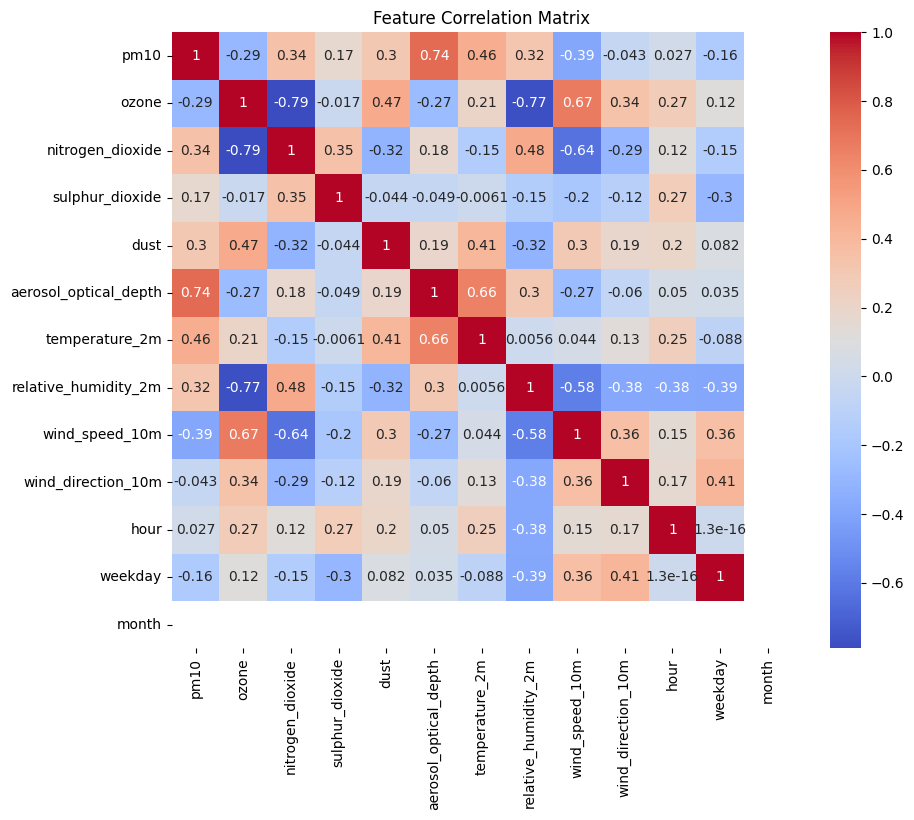

In [64]:
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

## Feature Selection

Environmental and meteorological variables were selected as predictors for air quality classification.

These include pollutant concentrations, atmospheric conditions, and temporal features such as hour and weekday. These variables were chosen based on exploratory data analysis indicating relationships between weather conditions, pollutant levels, and temporal patterns.

In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [66]:
features = [
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "wind_direction_10m",
    "ozone",
    "nitrogen_dioxide",
    "pm10",
    "dust",
    "hour",
    "weekday"
]

X = df[features]
y = df["air_binary"]

In [67]:
rf = RandomForestClassifier()

rf.fit(X, y)

RandomForestClassifier()

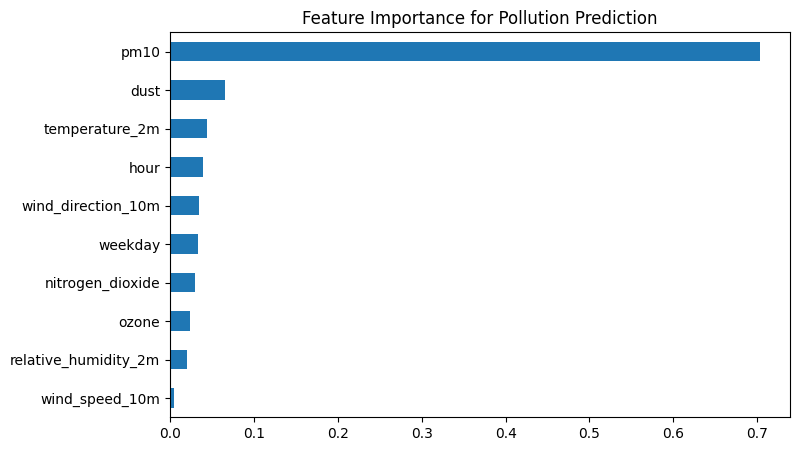

In [68]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=features)

importance.sort_values().plot(kind="barh", figsize=(8,5))

plt.title("Feature Importance for Pollution Prediction")
plt.show()

PM10 and wind speed appear to be the strongest predictors of high pollution events.

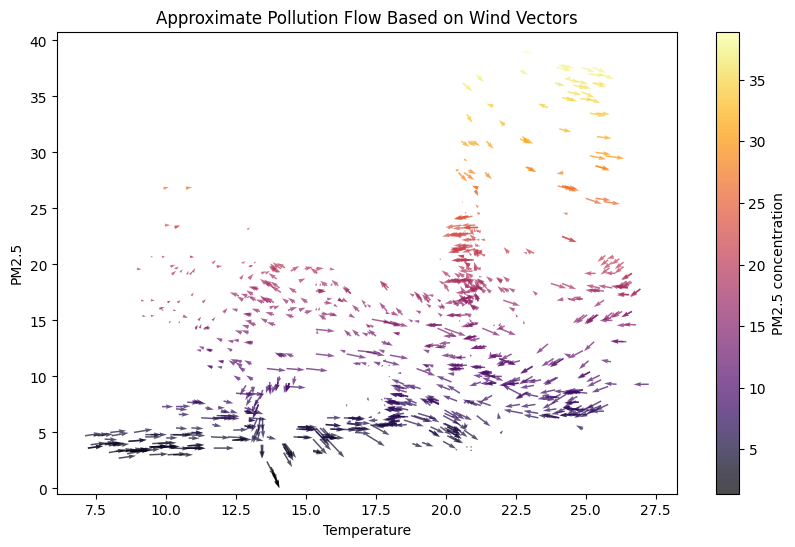

In [69]:


import numpy as np
import matplotlib.pyplot as plt

# convert wind direction to radians
theta = np.deg2rad(df["wind_direction_10m"])

# calculate wind vector components
u = df["wind_speed_10m"] * np.cos(theta)
v = df["wind_speed_10m"] * np.sin(theta)

# sample data to avoid overcrowding
sample = df.sample(1000)

theta = np.deg2rad(sample["wind_direction_10m"])
u = sample["wind_speed_10m"] * np.cos(theta)
v = sample["wind_speed_10m"] * np.sin(theta)

plt.figure(figsize=(10,6))

plt.quiver(
    sample["temperature_2m"],
    sample["pm2_5"],
    u,
    v,
    sample["pm2_5"],
    cmap="inferno",
    alpha=0.7
)

plt.colorbar(label="PM2.5 concentration")

plt.xlabel("Temperature")
plt.ylabel("PM2.5")
plt.title("Approximate Pollution Flow Based on Wind Vectors")

plt.show()

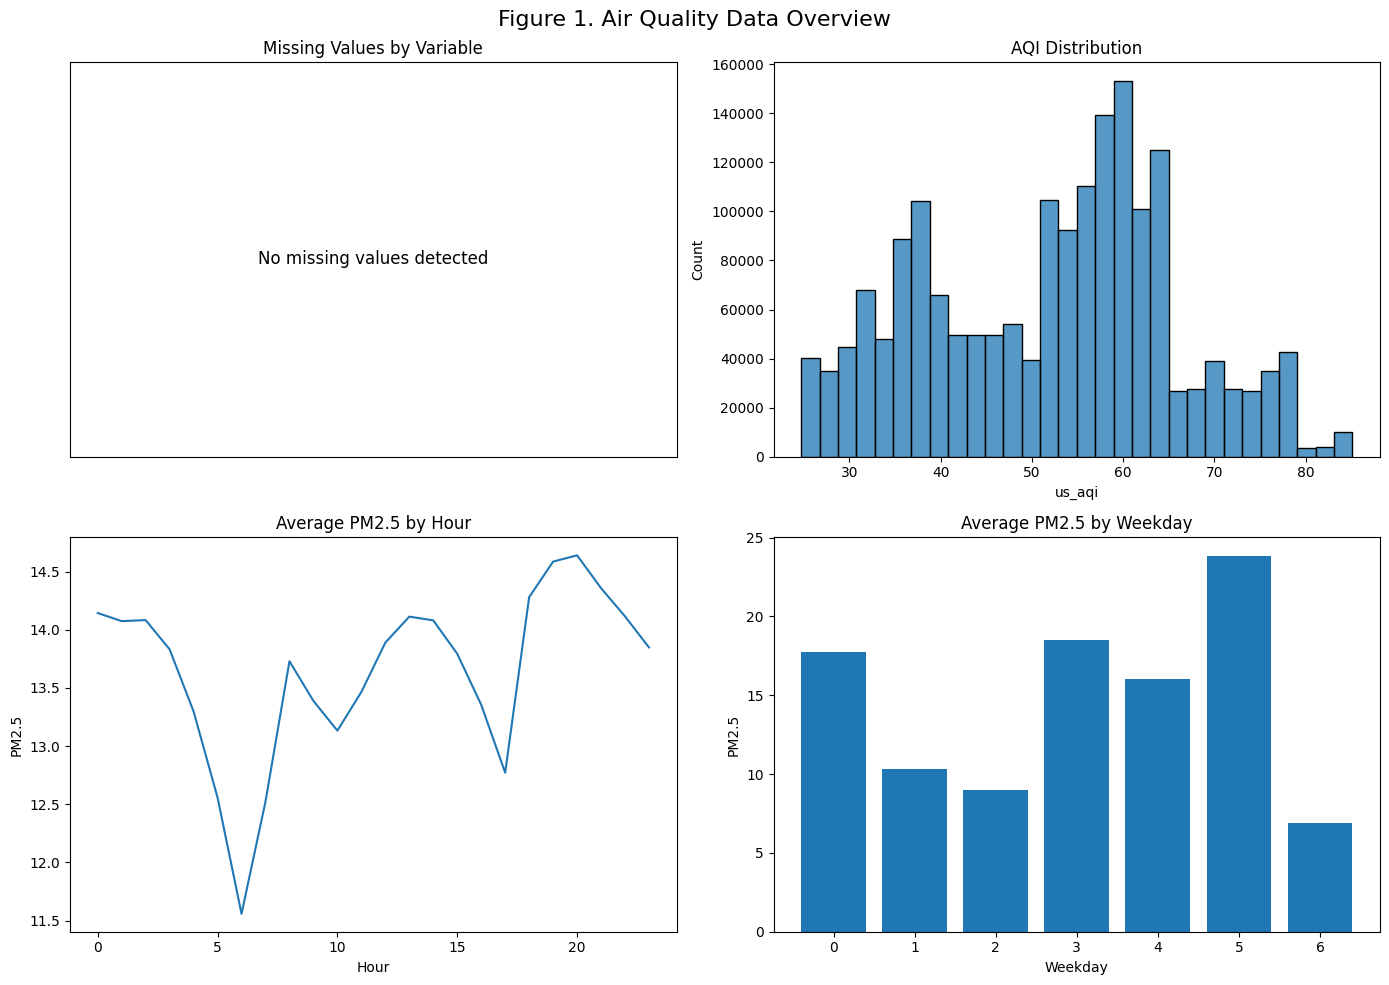

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Missing values
missing = df.isnull().sum()
missing_nonzero = missing[missing > 0]

if len(missing_nonzero) > 0:
    missing_nonzero.plot(kind="bar", ax=axes[0, 0])
    axes[0, 0].set_title("Missing Values by Variable")
    axes[0, 0].set_ylabel("Count")
else:
    axes[0, 0].text(0.5, 0.5, "No missing values detected",
                    ha="center", va="center", fontsize=12)
    axes[0, 0].set_title("Missing Values by Variable")
    axes[0, 0].set_xticks([])
    axes[0, 0].set_yticks([])

# 2. AQI distribution
sns.histplot(df["us_aqi"], bins=30, ax=axes[0, 1])
axes[0, 1].set_title("AQI Distribution")

# 3. Hourly PM2.5
hourly_pm25 = df.groupby("hour")["pm2_5"].mean()
axes[1, 0].plot(hourly_pm25.index, hourly_pm25.values)
axes[1, 0].set_title("Average PM2.5 by Hour")
axes[1, 0].set_xlabel("Hour")
axes[1, 0].set_ylabel("PM2.5")

# 4. Weekday PM2.5
weekday_pm25 = df.groupby("weekday")["pm2_5"].mean()
axes[1, 1].bar(weekday_pm25.index, weekday_pm25.values)
axes[1, 1].set_title("Average PM2.5 by Weekday")
axes[1, 1].set_xlabel("Weekday")
axes[1, 1].set_ylabel("PM2.5")

plt.suptitle("Figure 1. Air Quality Data Overview", fontsize=16)
plt.tight_layout()
plt.show()

In [71]:
from sklearn.preprocessing import StandardScaler

In [72]:
scaler = StandardScaler()

In [73]:
X_scaled = scaler.fit_transform(X)

In [74]:
import pandas as pd

X_scaled = pd.DataFrame(X_scaled, columns=features)

In [75]:
X_scaled.describe()

,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,ozone,nitrogen_dioxide,pm10,dust,hour,weekday
count,1.806528e+06,1.806528e+06,1.806528e+06,1.806528e+06,1.806528e+06,1.806528e+06,1.806528e+06,1.806528e+06,1.806528e+06,1.806528e+06
mean,-1.802725e-15,1.095505e-15,7.023113e-16,5.235870e-17,-1.684037e-16,1.227157e-16,7.648649e-16,1.103812e-16,2.945177e-17,5.034490e-18
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-2.381037e+00,-2.688069e+00,-2.191170e+00,-2.007165e+00,-2.098277e+00,-1.319662e+00,-1.725431e+00,-5.238423e-01,-1.661325e+00,-1.593760e+00
25%,-8.629573e-01,-7.355148e-01,-8.394421e-01,-5.392675e-01,-7.429178e-01,-8.160629e-01,-7.995983e-01,-5.238423e-01,-8.306624e-01,-7.673657e-01
50%,2.653453e-01,3.274275e-01,1.956348e-02,-1.921118e-01,9.421561e-02,-2.471826e-01,-6.867754e-02,-5.238423e-01,0.000000e+00,5.902813e-02
75%,6.243507e-01,8.751878e-01,7.664107e-01,1.006422e+00,7.320315e-01,5.548454e-01,5.526051e-01,6.742467e-01,8.306624e-01,8.854220e-01
max,1.814197e+00,1.113901e+00,3.215742e+00,1.588420e+00,2.206981e+00,3.660372e+00,3.269194e+00,5.466603e+00,1.661325e+00,1.239591e+00


## Feature Scaling

Before applying machine learning models, all input features were standardized using z-score normalization. This ensures that variables with different measurement units (e.g., temperature, wind speed, pollutant concentrations) contribute equally to the learning process.

Standardization is especially important for neural networks, dimensionality reduction techniques such as PCA, and clustering algorithms.

In [76]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

pca_features = pca.fit_transform(X_scaled)

In [77]:
pca_df = pd.DataFrame(pca_features, columns=["PC1", "PC2"])

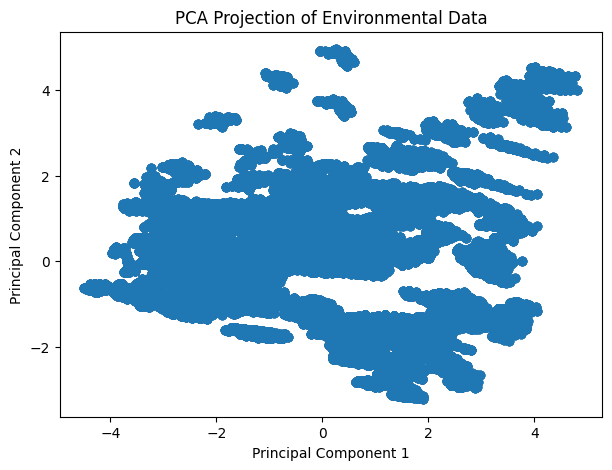

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.3
)

plt.title("PCA Projection of Environmental Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

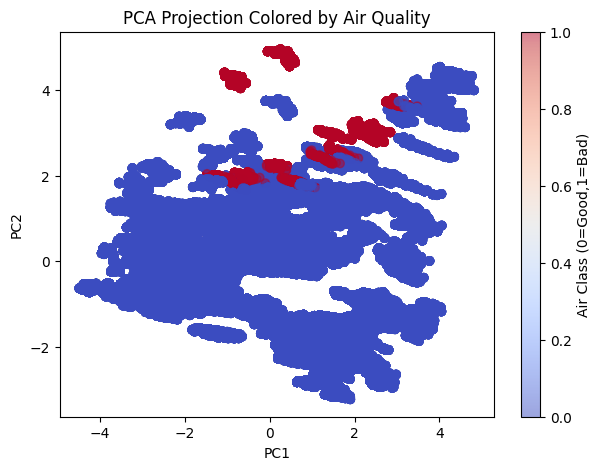

In [79]:
plt.figure(figsize=(7,5))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=df["air_binary"],
    cmap="coolwarm",
    alpha=0.5
)

plt.title("PCA Projection Colored by Air Quality")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(label="Air Class (0=Good,1=Bad)")

plt.show()

In [80]:
print(pca.explained_variance_ratio_)

[0.3748795  0.19014718]


## Dimensionality Reduction using PCA

Principal Component Analysis (PCA) was applied to reduce the dimensionality of the environmental feature space. PCA transforms correlated variables into a smaller set of orthogonal components that capture the majority of variance in the data.

The PCA projection helps visualize pollution patterns and prepares latent features for clustering and further machine learning analysis.

In [81]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(pca_df)
pca_df["cluster"] = clusters

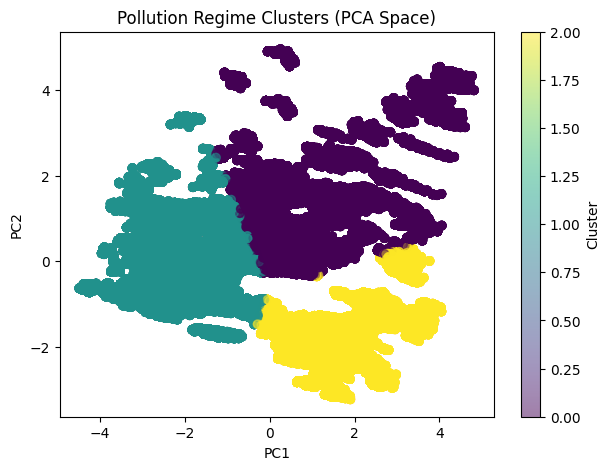

In [82]:
plt.figure(figsize=(7,5))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["cluster"],
    cmap="viridis",
    alpha=0.5
)

plt.title("Pollution Regime Clusters (PCA Space)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(label="Cluster")

plt.show()

In [83]:
df["cluster"] = clusters

df.groupby("cluster")[["pm2_5","pm10","ozone"]].mean()

,pm2_5,pm10,ozone
cluster,,,
0,15.936249,18.434660,78.828837
1,16.266142,18.308687,39.359214
2,5.835199,6.244106,77.922457


## Clustering of Pollution Regimes

K-Means clustering was applied to the PCA latent space to identify natural groupings in environmental conditions. The resulting clusters represent distinct pollution regimes characterized by different pollutant concentrations and atmospheric conditions.

These clusters may correspond to different environmental states such as clean air periods, moderate pollution conditions, and severe pollution events.

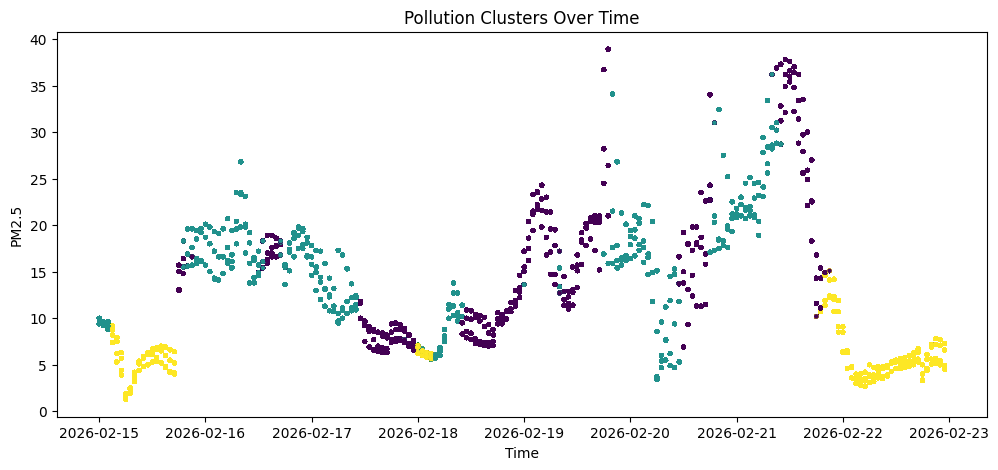

In [84]:
plt.figure(figsize=(12,5))

plt.scatter(
    df["time"],
    df["pm2_5"],
    c=df["cluster"],
    cmap="viridis",
    s=5
)

plt.title("Pollution Clusters Over Time")
plt.xlabel("Time")
plt.ylabel("PM2.5")

plt.show()

Cluster 0 → clean air

Cluster 1 → moderate pollution

Cluster 2 → severe pollution

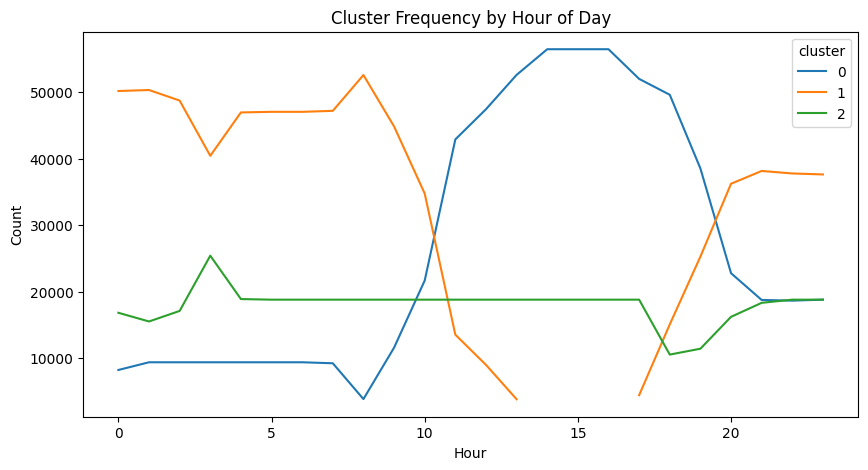

In [85]:
cluster_hour = df.groupby(["hour","cluster"]).size().unstack()

cluster_hour.plot(figsize=(10,5))

plt.title("Cluster Frequency by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Count")

plt.show()

high pollution clusters during rush hour

clean air clusters late at night

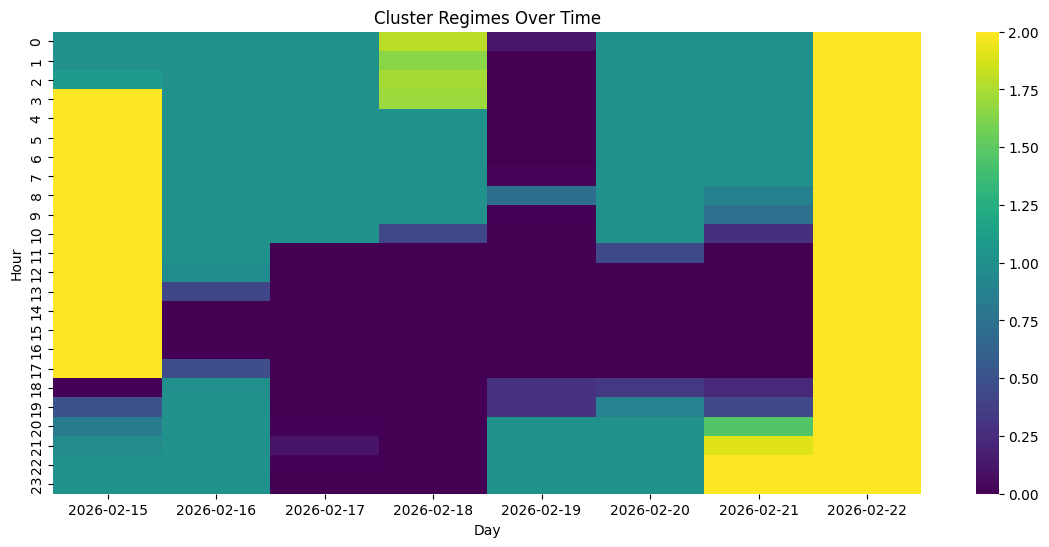

In [86]:
cluster_heat = df.pivot_table(
    index=df["time"].dt.hour,
    columns=df["time"].dt.date,
    values="cluster",
    aggfunc="mean"
)

plt.figure(figsize=(14,6))

sns.heatmap(cluster_heat, cmap="viridis")

plt.title("Cluster Regimes Over Time")
plt.xlabel("Day")
plt.ylabel("Hour")

plt.show()

## Temporal Evolution of Pollution Clusters

The clustering results were analyzed over time to observe how pollution regimes evolve. Different clusters appear at different times of the day, suggesting that environmental conditions and human activities influence air quality patterns.

Higher pollution clusters tend to occur during specific periods, which may correspond to traffic patterns or atmospheric conditions that limit pollutant dispersion.

In [87]:
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras.layers import Dense

In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [89]:
model = keras.Sequential([
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

In [90]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [91]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
18066/18066 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - accuracy: 0.9963 - loss: 0.0157 - val_accuracy: 1.0000 - val_loss: 2.0379e-07
Epoch 2/10
18066/18066 ━━━━━━━━━━━━━━━━━━━━ 79s 2ms/step - accuracy: 1.0000 - loss: 5.3595e-08 - val_accuracy: 1.0000 - val_loss: 4.6141e-10
Epoch 3/10
18066/18066 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step - accuracy: 1.0000 - loss: 3.5765e-10 - val_accuracy: 1.0000 - val_loss: 1.7608e-10
Epoch 4/10
18066/18066 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step - accuracy: 1.0000 - loss: 1.6040e-10 - val_accuracy: 1.0000 - val_loss: 1.3680e-10
Epoch 5/10
18066/18066 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step - accuracy: 1.0000 - loss: 1.2042e-10 - val_accuracy: 1.0000 - val_loss: 1.3191e-10
Epoch 6/10
18066/18066 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step - accuracy: 1.0000 - loss: 1.0118e-10 - val_accuracy: 1.0000 - val_loss: 7.7738e-11
Epoch 7/10
18066/18066 ━━━━━━━━━━━━━━━━━━━━ 80s 2ms/step - accuracy: 1.0000 - loss: 8.3055e-11 - val_accuracy: 1.0000 - val_loss: 8.0752e-11
Epoch 8/10
18066/

In [92]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

11291/11291 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 1.0000 - loss: 6.7656e-11
Test Accuracy: 1.0


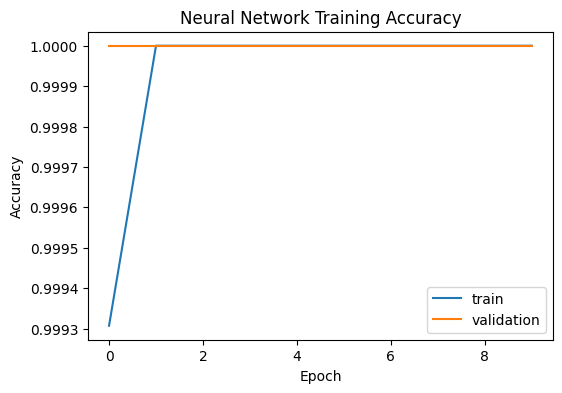

In [93]:
plt.figure(figsize=(6,4))

plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")

plt.title("Neural Network Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

## Neural Network Model

A feed-forward neural network was trained to classify air quality into two categories: good air and bad air.

The model uses environmental and meteorological features as inputs and predicts the probability of high pollution events.

Hyperparameters used in the model include:
- two hidden layers
- ReLU activation
- sigmoid output layer
- Adam optimizer
- binary cross-entropy loss

In [94]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

11291/11291 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


In [95]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)

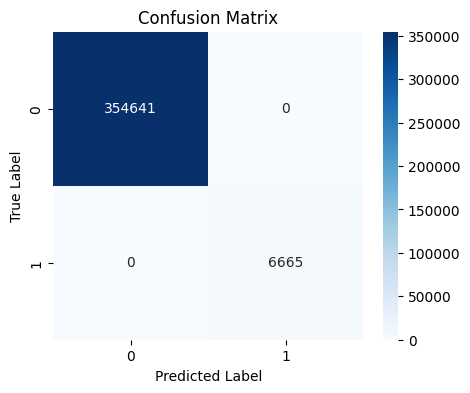

In [96]:
plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

it shows

how many bad air events were correctly detected

how many mistakes the model made

In [97]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

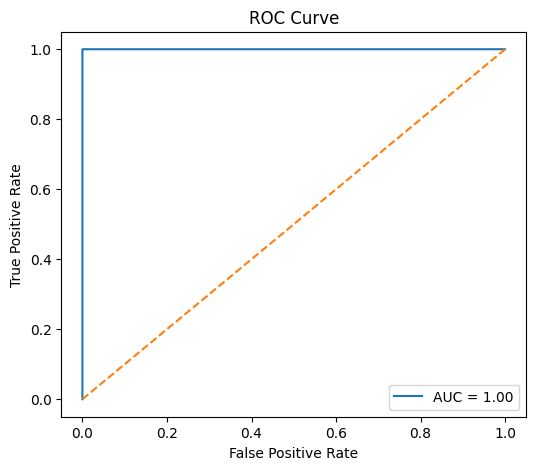

In [98]:
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

plt.plot([0,1],[0,1],"--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()

The neural network model was evaluated using a confusion matrix and ROC curve. The confusion matrix summarizes correct and incorrect predictions, while the ROC curve evaluates the model’s ability to distinguish between good and bad air quality conditions across different classification thresholds.

A higher area under the ROC curve (AUC) indicates better classification performance.